In [47]:
print(1)

1


In [48]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Input data 
url = 'data/forestfires.csv'
dataGEO = gpd.read_file(url)
data2 = pd.read_csv(url)

dataGEOshow = gpd.read_file(url).head()
dataGEOshow

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0,0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18,33,0.9,0,0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0,0
3,8,6,mar,fri,91.7,33.3,77.5,9,8.3,97,4,0.2,0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0,0


In [50]:
summer_months = ['jun', 'jul', 'aug', 'sep']
data2 = data2[data2['month'].isin(summer_months)].copy()

In [ ]:
data2.head()

In [52]:
# dataGEO = dataGEO[dataGEO['month'].isin(summer_months)].copy
dataGEO = dataGEO

In [ ]:
dataGEO

<Axes: >

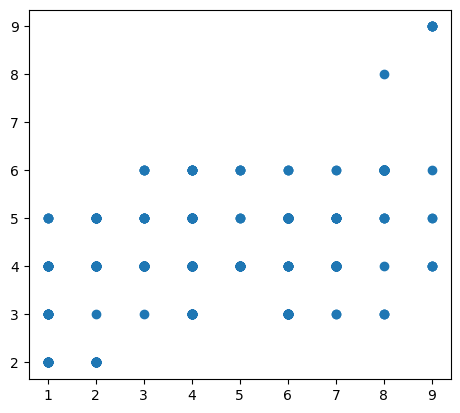

In [55]:
from shapely.geometry import Point

geometry = [Point(xy) for xy in zip(dataGEO["X"], dataGEO["Y"])]

gdf = gpd.GeoDataFrame(dataGEO, geometry=geometry)

gdf.plot()

In [58]:
data2.drop(['month'], inplace=True, axis=1)
data2.drop(['day'], inplace=True, axis=1)

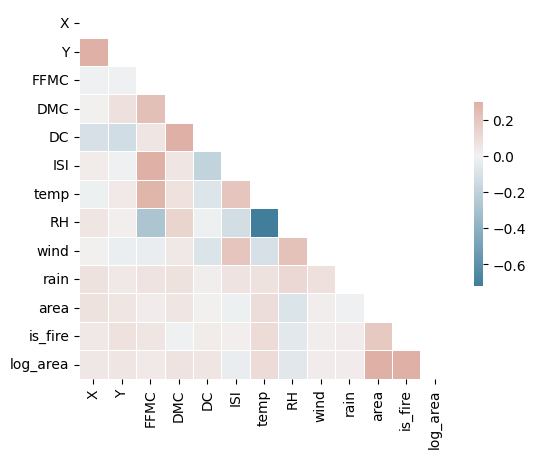

In [59]:

cmap = sns.diverging_palette(230, 20, as_cmap=True) # like this 

corr = data2.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr,
    mask=mask,
    cmap=cmap,
    vmax=.3,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .5}
)

plt.show()

In [ ]:
data2

In [60]:
# without AI
num_df = data2

num_df["is_fire"] = (num_df["area"] > 0).astype(int)

print(num_df["is_fire"].value_counts())

is_fire
1    222
0    183
Name: count, dtype: int64


In [61]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
model = RandomForestRegressor(max_depth=20,n_estimators=200,random_state=42)

In [62]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data2['log_area'] = np.log1p(data2['area'])

data_encoded = data2

X = data_encoded.drop(['area','log_area','ISI' ,'X',], axis=1) #  'RH',
y = data_encoded['log_area']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [63]:
model.fit(X_train, y_train)


,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [64]:
y_train_pred = model.predict(X_train)

In [65]:
from sklearn.model_selection import GridSearchCV

model = RandomForestRegressor()

In [66]:
CV = 3

In [67]:
params = {'n_estimators':[50,100,200,3000],
          'max_depth':[1,10,20,100]}

In [68]:
gsff = GridSearchCV(model,params,cv=CV,n_jobs=-1)

In [69]:
gsff.fit(X_train, y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [1, 10, ...], 'n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,50


In [70]:
model.fit(X_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [71]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error


y_train_pred = model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

print("TRAIN MAE:", mae_train)
print("TRAIN RMSE:", rmse_train)
print("TRAIN R2:", r2_train)

TRAIN MAE: 0.23795253382247147
TRAIN RMSE: 0.40525526518329097
TRAIN R2: 0.9200474660191181


In [72]:
# predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("=== TRAIN ===")
print("MAE:", mean_absolute_error(y_train, y_train_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("R2:", r2_score(y_train, y_train_pred))

print("\n=== TEST ===")
print("MAE:", mean_absolute_error(y_test, y_test_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("R2:", r2_score(y_test, y_test_pred))

=== TRAIN ===
MAE: 0.23795253382247147
RMSE: 0.40525526518329097
R2: 0.9200474660191181

=== TEST ===
MAE: 0.49234970988289745
RMSE: 0.9073082739278862
R2: 0.5589184131569029
